## Cell 1 — Install Dependencies

In [39]:
import subprocess, sys

packages = [
    'pandas', 'numpy', 'scikit-learn', 'xgboost',
    'shap', 'matplotlib', 'seaborn', 'joblib', 'tqdm'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print(' All packages installed')

 All packages installed


## Cell 2 — Imports & Configuration

In [40]:
# ── Standard Library 
import warnings
import json
import os
import re
import time
from datetime import datetime

# ── Data 
import numpy as np
import pandas as pd

# ── ML 
from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      f1_score, roc_auc_score, roc_curve,
                                      precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.pipeline         import Pipeline
from sklearn.calibration      import CalibratedClassifierCV
import xgboost as xgb
import shap
import joblib

# ── Visualization 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')

# ── Configuration 
CONFIG = {
    'DATA_PATH'        : 'email_security_dataset.csv',
    'MODEL_DIR'        : 'models/',
    'TEST_SIZE'        : 0.20,   # 80/20 train-test split
    'VAL_SIZE'         : 0.10,   # 10% of train for validation
    'RANDOM_STATE'     : 42,
    'CV_FOLDS'         : 5,

    # Decision thresholds (tune these for your use case)
    'BLOCK_THRESHOLD'      : 0.80,  # >= 80% → BLOCK
    'QUARANTINE_THRESHOLD' : 0.50,  # >= 50% → QUARANTINE
    # < 50% → ALLOW

    # Rule engine weights
    'RULE_WEIGHT' : 0.35,
    'ML_WEIGHT'   : 0.65,
}

os.makedirs(CONFIG['MODEL_DIR'], exist_ok=True)
print(' Imports complete')
print(f"   Block threshold     : {CONFIG['BLOCK_THRESHOLD']}")
print(f"   Quarantine threshold: {CONFIG['QUARANTINE_THRESHOLD']}")
print(f"   Rule / ML weight    : {CONFIG['RULE_WEIGHT']} / {CONFIG['ML_WEIGHT']}")

 Imports complete
   Block threshold     : 0.8
   Quarantine threshold: 0.5
   Rule / ML weight    : 0.35 / 0.65


## Cell 3 — Load & Explore Dataset

In [41]:
# ── Load 
print(f" Loading: {CONFIG['DATA_PATH']}")
df = pd.read_csv(CONFIG['DATA_PATH'])

print(f' Loaded  : {len(df):,} records | {len(df.columns)} columns')
print(f'\n Label distribution:')
print(df['label'].value_counts())
print(f'\n Class balance:')
print(df['label'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print(f'\n Missing values:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '   None ')

print(f'\n Sample record (phishing):')
display(df[df['label']=='phishing'][[
    'from','spf_result','dkim_result','dmarc_result',
    'attack_pattern','is_spoofed','x_spam_score','label'
]].head(2))

 Loading: email_security_dataset.csv
 Loaded  : 100,000 records | 39 columns

 Label distribution:
label
legitimate    60000
spam          25000
phishing      15000
Name: count, dtype: int64

 Class balance:
label
legitimate    60.0%
spam          25.0%
phishing      15.0%
Name: proportion, dtype: str

 Missing values:
   None 

 Sample record (phishing):


,from,spf_result,dkim_result,dmarc_result,attack_pattern,is_spoofed,x_spam_score,label
0,lindsay78@bankofamerica-secure.ml,fail,fail,quarantine,display_name_spoofing,True,6.07,phishing
3,josephbrennan@account-update.info,softfail,none,fail,lookalike_domain,False,6.55,phishing


## Cell 4 — Feature Engineering

In [42]:

#  FEATURE ENGINEERING
#  Convert raw header fields into numeric ML features


def engineer_features(df):
    """
    Transform raw email header fields into numeric features for ML.
    All features are derived from security headers only.
    """
    feat = pd.DataFrame()

    # ── SPF Features
    spf_map = {'pass':4, 'neutral':3, 'softfail':2, 'none':1, 'fail':0, 'permerror':0}
    feat['spf_score']         = df['spf_result'].map(spf_map).fillna(0)
    feat['spf_pass']          = (df['spf_result'] == 'pass').astype(int)
    feat['spf_fail']          = (df['spf_result'].isin(['fail','permerror'])).astype(int)
    feat['spf_softfail']      = (df['spf_result'] == 'softfail').astype(int)
    feat['spf_none']          = (df['spf_result'] == 'none').astype(int)

    # ── DKIM Features 
    dkim_map = {'pass':3, 'none':1, 'fail':0, 'temperror':0}
    feat['dkim_score']        = df['dkim_result'].map(dkim_map).fillna(0)
    feat['dkim_pass']         = (df['dkim_result'] == 'pass').astype(int)
    feat['dkim_fail']         = (df['dkim_result'].isin(['fail','temperror'])).astype(int)
    feat['dkim_none']         = (df['dkim_result'] == 'none').astype(int)

    # ── DMARC Features 
    dmarc_res_map  = {'pass':3, 'none':2, 'quarantine':1, 'fail':0, 'reject':0}
    dmarc_pol_map  = {'reject':3, 'quarantine':2, 'none':1}
    feat['dmarc_result_score']   = df['dmarc_result'].map(dmarc_res_map).fillna(0)
    feat['dmarc_policy_score']   = df['dmarc_policy'].map(dmarc_pol_map).fillna(0)
    feat['dmarc_pass']           = (df['dmarc_result'] == 'pass').astype(int)
    feat['dmarc_fail']           = (df['dmarc_result'].isin(['fail','reject'])).astype(int)
    feat['dmarc_align_spf']      = (df['dmarc_alignment_spf']  == 'pass').astype(int)
    feat['dmarc_align_dkim']     = (df['dmarc_alignment_dkim'] == 'pass').astype(int)
    feat['dmarc_both_aligned']   = (feat['dmarc_align_spf'] & feat['dmarc_align_dkim']).astype(int)
    feat['dmarc_none_align']     = (~feat['dmarc_align_spf'].astype(bool) &
                                    ~feat['dmarc_align_dkim'].astype(bool)).astype(int)

    # ── Combined Auth Score 
    # SPF+DKIM+DMARC all pass = max trust
    feat['all_auth_pass']     = (feat['spf_pass'] & feat['dkim_pass'] & feat['dmarc_pass']).astype(int)
    feat['auth_failures']     = feat['spf_fail'] + feat['dkim_fail'] + feat['dmarc_fail']
    feat['auth_total_score']  = feat['spf_score'] + feat['dkim_score'] + feat['dmarc_result_score']

    # ── Domain Features 
    feat['domain_aligned']    = df['domain_alignment_match'].astype(int)
    feat['is_spoofed']        = df['is_spoofed'].astype(int)

    # Domain length (phishing domains tend to be longer)
    feat['header_domain_len'] = df['header_from_domain'].str.len().fillna(0)
    feat['envelope_domain_len']= df['envelope_from_domain'].str.len().fillna(0)
    feat['domain_len_diff']   = abs(feat['header_domain_len'] - feat['envelope_domain_len'])

    # TLD suspiciousness (known risky TLDs)
    risky_tlds = {'xyz','tk','ml','gq','cf','pw','cc','ru','info','biz','win'}
    def tld_risk(domain):
        if pd.isna(domain): return 0
        tld = str(domain).split('.')[-1].lower()
        return 1 if tld in risky_tlds else 0
    feat['header_domain_risky_tld']   = df['header_from_domain'].apply(tld_risk)
    feat['envelope_domain_risky_tld'] = df['envelope_from_domain'].apply(tld_risk)

    # Digit in domain (paypa1.com style)
    def has_digit_in_domain(domain):
        if pd.isna(domain): return 0
        name = str(domain).split('.')[0]
        return 1 if any(c.isdigit() for c in name) else 0
    feat['digit_in_header_domain']   = df['header_from_domain'].apply(has_digit_in_domain)
    feat['digit_in_envelope_domain'] = df['envelope_from_domain'].apply(has_digit_in_domain)

    # Hyphen in domain (secure-login.xyz style)
    feat['hyphen_in_domain'] = df['header_from_domain'].str.contains('-', na=False).astype(int)

    # ── Routing Features 
    feat['hop_count']         = df['hop_count'].fillna(1)
    feat['high_hop_count']    = (feat['hop_count'] >= 5).astype(int)

    # Reply-To mismatch (header from vs reply-to domain differ)
    def reply_to_mismatch(row):
        try:
            rt = str(row['reply_to']).split('@')[-1].replace('>', '').strip()
            hd = str(row['header_from_domain']).strip()
            return 0 if rt == hd else 1
        except:
            return 0
    feat['reply_to_mismatch'] = df.apply(reply_to_mismatch, axis=1)

    # ── Reputation Features 
    feat['spam_score']        = df['x_spam_score'].fillna(0)
    feat['spam_score_high']   = (df['x_spam_score'] >= 5.0).astype(int)
    feat['spam_score_very_high'] = (df['x_spam_score'] >= 8.0).astype(int)

    # ── ARC Features 
    feat['arc_fail'] = df['arc_seal'].str.contains('cv=fail', na=False).astype(int)
    feat['arc_pass'] = df['arc_seal'].str.contains('cv=pass', na=False).astype(int)

    # ── Interaction Features 
    # SPF fail + DKIM fail (very suspicious)
    feat['spf_dkim_both_fail']   = (feat['spf_fail'] & feat['dkim_fail']).astype(int)
    # Spoofed + high spam score
    feat['spoofed_and_spammy']   = (feat['is_spoofed'] & feat['spam_score_high']).astype(int)
    # Domain misaligned + DMARC fail
    feat['misalign_dmarc_fail']  = (~feat['domain_aligned'].astype(bool) &
                                     feat['dmarc_fail'].astype(bool)).astype(int)
    # Risky TLD + auth failure
    feat['risky_tld_auth_fail']  = (feat['header_domain_risky_tld'] &
                                    (feat['auth_failures'] > 0)).astype(int)

    for col in ['spam_score', 'spam_score_high', 'spam_score_very_high',
                'spoofed_and_spammy']:
        if col in feat.columns:
            feat.drop(columns=[col], inplace=True)

    return feat


print('  Engineering features...')
X = engineer_features(df)
y = df['label']

print(f' Features engineered: {X.shape[1]} features × {X.shape[0]:,} samples')
print(f'\n Feature list:')
for i, col in enumerate(X.columns, 1):
    print(f'   {i:2d}. {col}')

  Engineering features...
 Features engineered: 38 features × 100,000 samples

 Feature list:
    1. spf_score
    2. spf_pass
    3. spf_fail
    4. spf_softfail
    5. spf_none
    6. dkim_score
    7. dkim_pass
    8. dkim_fail
    9. dkim_none
   10. dmarc_result_score
   11. dmarc_policy_score
   12. dmarc_pass
   13. dmarc_fail
   14. dmarc_align_spf
   15. dmarc_align_dkim
   16. dmarc_both_aligned
   17. dmarc_none_align
   18. all_auth_pass
   19. auth_failures
   20. auth_total_score
   21. domain_aligned
   22. is_spoofed
   23. header_domain_len
   24. envelope_domain_len
   25. domain_len_diff
   26. header_domain_risky_tld
   27. envelope_domain_risky_tld
   28. digit_in_header_domain
   29. digit_in_envelope_domain
   30. hyphen_in_domain
   31. hop_count
   32. high_hop_count
   33. reply_to_mismatch
   34. arc_fail
   35. arc_pass
   36. spf_dkim_both_fail
   37. misalign_dmarc_fail
   38. risky_tld_auth_fail


## Cell 5 — Rule-Based Engine (Layer 1)

In [45]:
#  LAYER 1: RULE-BASED ENGINE
#  Hard rules based on RFC standards and security best practices
#  Returns: rule_score (0.0-1.0) + list of triggered rules

# Known malicious domain fragments (expandable blocklist)
PHISH_DOMAIN_PATTERNS = [
    r'paypa[l1]', r'amaz[o0]n', r'micros[o0]ft', r'g[o0]{2}gle',
    r'secure-login', r'account-verify', r'account-update',
    r'urgent-action', r'security-alert', r'login-secure',
    r'verify-account', r'support-helpdesk', r'noreply-security',
]

RISKY_TLDS = {'xyz','tk','ml','gq','cf','pw','cc','info','win','top','click'}


class RuleEngine:
    

    def __init__(self):
        self.rules = [
            self._rule_spf_fail,
            self._rule_dkim_fail,
            self._rule_dmarc_fail,
            self._rule_domain_misalignment,
            self._rule_reply_to_hijack,
            self._rule_risky_tld,
            self._rule_lookalike_domain,
            self._rule_high_hop_count,
            self._rule_high_spam_score,
            self._rule_spf_dkim_both_fail,
            self._rule_dmarc_none_policy,
            self._rule_arc_fail,
            self._rule_digit_in_domain,
            self._rule_hyphen_domain,
            self._rule_all_auth_pass,   # Trust booster (negative risk)
        ]

    def evaluate(self, record: dict) -> dict:
       
        triggered = []
        total_score = 0.0

        for rule_fn in self.rules:
            score, flag, reason = rule_fn(record)
            total_score += score
            if flag:
                triggered.append({'rule': flag, 'score': score, 'reason': reason})

        # Normalize to 0.0 - 1.0
        rule_score = min(max(total_score / 10.0, 0.0), 1.0)

        if rule_score >= 0.70:
            verdict = 'BLOCK'
        elif rule_score >= 0.40:
            verdict = 'QUARANTINE'
        else:
            verdict = 'ALLOW'

        return {
            'rule_score'     : round(rule_score, 4),
            'triggered_rules': triggered,
            'rule_verdict'   : verdict,
            'rule_flag_count': len(triggered),
        }

    # ── Individual Rules ──────────────────────────────────

    def _rule_spf_fail(self, r):
        if r.get('spf_result') == 'fail':
            return 2.5, 'SPF_FAIL', 'SPF check failed: sending IP not authorized by domain'
        if r.get('spf_result') == 'softfail':
            return 1.2, 'SPF_SOFTFAIL', 'SPF softfail: sending IP weakly unauthorized'
        if r.get('spf_result') == 'none':
            return 0.8, 'SPF_NONE', 'No SPF record found for sending domain'
        return 0, None, None

    def _rule_dkim_fail(self, r):
        if r.get('dkim_result') == 'fail':
            return 2.5, 'DKIM_FAIL', 'DKIM signature invalid: message may have been tampered'
        if r.get('dkim_result') == 'none':
            return 0.8, 'DKIM_NONE', 'No DKIM signature found'
        return 0, None, None

    def _rule_dmarc_fail(self, r):
        if r.get('dmarc_result') in ('fail', 'reject'):
            return 2.0, 'DMARC_FAIL', 'DMARC authentication failed: domain policy violation'
        if r.get('dmarc_result') == 'quarantine':
            return 1.5, 'DMARC_QUARANTINE', 'DMARC policy requires quarantine'
        return 0, None, None

    def _rule_domain_misalignment(self, r):
        hd = str(r.get('header_from_domain', ''))
        ed = str(r.get('envelope_from_domain', ''))
        if hd != ed and hd and ed:
            return 2.0, 'DOMAIN_MISALIGNMENT',\
                f'Header domain ({hd}) ≠ Envelope domain ({ed}): possible spoofing'
        return 0, None, None

    def _rule_reply_to_hijack(self, r):
        try:
            rt = str(r.get('reply_to', '')).split('@')[-1].replace('>', '').strip()
            hd = str(r.get('header_from_domain', '')).strip()
            if rt and hd and rt != hd:
                return 1.5, 'REPLY_TO_HIJACK',\
                    f'Reply-To domain ({rt}) differs from sender domain ({hd})'
        except:
            pass
        return 0, None, None

    def _rule_risky_tld(self, r):
        domain = str(r.get('header_from_domain', ''))
        tld = domain.split('.')[-1].lower() if '.' in domain else ''
        if tld in RISKY_TLDS:
            return 1.5, 'RISKY_TLD', f'Sender uses high-risk TLD: .{tld}'
        return 0, None, None

    def _rule_lookalike_domain(self, r):
        domain = str(r.get('header_from_domain', '')).lower()
        for pattern in PHISH_DOMAIN_PATTERNS:
            if re.search(pattern, domain):
                return 3.0, 'LOOKALIKE_DOMAIN',\
                    f'Domain matches known phishing pattern: {domain}'
        return 0, None, None

    def _rule_high_hop_count(self, r):
        hops = int(r.get('hop_count', 0))
        if hops >= 6:
            return 1.5, 'EXCESSIVE_HOPS',\
                f'Unusual routing: {hops} hops (possible obfuscation)'
        if hops >= 4:
            return 0.5, 'HIGH_HOPS', f'Above-average routing hops: {hops}'
        return 0, None, None

    def _rule_high_spam_score(self, r):
        score = float(r.get('x_spam_score', 0))
        if score >= 8.0:
            return 2.5, 'VERY_HIGH_SPAM_SCORE', f'X-Spam-Score critically high: {score}'
        if score >= 5.0:
            return 1.5, 'HIGH_SPAM_SCORE', f'X-Spam-Score above threshold: {score}'
        return 0, None, None

    def _rule_spf_dkim_both_fail(self, r):
        spf_bad  = r.get('spf_result')  in ('fail', 'softfail', 'none')
        dkim_bad = r.get('dkim_result') in ('fail', 'none')
        if spf_bad and dkim_bad:
            return 2.0, 'SPF_DKIM_BOTH_FAIL',\
                'Both SPF and DKIM failed/missing: high confidence threat'
        return 0, None, None

    def _rule_dmarc_none_policy(self, r):
        if r.get('dmarc_policy') == 'none' and r.get('dmarc_result') != 'pass':
            return 1.0, 'DMARC_NONE_POLICY',\
                'DMARC policy=none: domain owner not enforcing protection'
        return 0, None, None

    def _rule_arc_fail(self, r):
        arc = str(r.get('arc_seal', ''))
        if 'cv=fail' in arc:
            return 1.0, 'ARC_CHAIN_FAIL',\
                'ARC chain validation failed: forwarding integrity broken'
        return 0, None, None

    def _rule_digit_in_domain(self, r):
        domain = str(r.get('header_from_domain', '')).split('.')[0]
        if any(c.isdigit() for c in domain):
            return 1.0, 'DIGIT_IN_DOMAIN',\
                f'Digits in domain name: possible typosquatting ({r.get("header_from_domain")})'
        return 0, None, None

    def _rule_hyphen_domain(self, r):
        domain = str(r.get('header_from_domain', ''))
        if domain.count('-') >= 2:
            return 0.8, 'EXCESSIVE_HYPHENS',\
                f'Multiple hyphens in domain: common phishing pattern ({domain})'
        return 0, None, None

    def _rule_all_auth_pass(self, r):
        """Trust booster: if everything passes, reduce suspicion score"""
        if (r.get('spf_result')  == 'pass' and
            r.get('dkim_result') == 'pass' and
            r.get('dmarc_result')== 'pass' and
            r.get('domain_alignment_match') == True):
            return -2.0, None, None  # Reduce risk score
        return 0, None, None


# ── Test rule engine on samples ───────────────────────────
rule_engine = RuleEngine()

sample_phish = df[df['label']=='phishing'].iloc[0].to_dict()
result = rule_engine.evaluate(sample_phish)

print(' Rule Engine initialized and tested')
print(f"\n Sample phishing email evaluation:")
print(f"   Rule score : {result['rule_score']}")
print(f"   Verdict    : {result['rule_verdict']}")
print(f"   Flags ({result['rule_flag_count']}):")
for flag in result['triggered_rules']:
    print(f"     [{flag['score']:+.1f}] {flag['rule']:30s} — {flag['reason']}")

 Rule Engine initialized and tested

 Sample phishing email evaluation:
   Rule score : 1.0
   Verdict    : BLOCK
   Flags (9):
     [+2.5] SPF_FAIL                       — SPF check failed: sending IP not authorized by domain
     [+2.5] DKIM_FAIL                      — DKIM signature invalid: message may have been tampered
     [+1.5] DMARC_QUARANTINE               — DMARC policy requires quarantine
     [+2.0] DOMAIN_MISALIGNMENT            — Header domain (bankofamerica-secure.ml) ≠ Envelope domain (amazon-verify.ru): possible spoofing
     [+1.5] RISKY_TLD                      — Sender uses high-risk TLD: .ml
     [+1.5] HIGH_SPAM_SCORE                — X-Spam-Score above threshold: 6.07
     [+2.0] SPF_DKIM_BOTH_FAIL             — Both SPF and DKIM failed/missing: high confidence threat
     [+1.0] DMARC_NONE_POLICY              — DMARC policy=none: domain owner not enforcing protection
     [+1.0] ARC_CHAIN_FAIL                 — ARC chain validation failed: forwarding integrity

## Cell 6 — Train/Test Split & Preprocessing

In [46]:
# ── Label Encoding 
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

#  Train / Validation / Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size    = CONFIG['TEST_SIZE'],
    random_state = CONFIG['RANDOM_STATE'],
    stratify     = y_encoded
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size    = CONFIG['VAL_SIZE'] / (1 - CONFIG['TEST_SIZE']),
    random_state = CONFIG['RANDOM_STATE'],
    stratify     = y_train
)

print(f'\n Data split:')
print(f'   Train      : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'   Validation : {len(X_val):,} ({len(X_val)/len(X)*100:.0f}%)')
print(f'   Test       : {len(X_test):,} ({len(X_test)/len(X)*100:.0f}%)')


_, test_idx = train_test_split(
    df.index, test_size=CONFIG['TEST_SIZE'],
    random_state=CONFIG['RANDOM_STATE'], stratify=y_encoded
)
df_test = df.loc[test_idx].reset_index(drop=True)

print(f'\n Splits ready')

Label mapping: {'legitimate': np.int64(0), 'phishing': np.int64(1), 'spam': np.int64(2)}

 Data split:
   Train      : 70,000 (70%)
   Validation : 10,000 (10%)
   Test       : 20,000 (20%)

 Splits ready


## Cell 7 — Train Random Forest

In [47]:
#  LAYER 2a: RANDOM FOREST CLASSIFIER

print(' Training Random Forest...')
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators      = 300,
    max_depth         = 20,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = 'sqrt',
    class_weight      = 'balanced',   # handles class imbalance
    n_jobs            = -1,
    random_state      = CONFIG['RANDOM_STATE'],
    oob_score         = True,
)

rf_model.fit(X_train, y_train)
elapsed = time.time() - t0

# Validation metrics
y_val_pred_rf = rf_model.predict(X_val)
val_f1_rf = f1_score(y_val, y_val_pred_rf, average='weighted')

print(f' Random Forest trained in {elapsed:.1f}s')
print(f'   OOB Score        : {rf_model.oob_score_:.4f}')
print(f'   Validation F1    : {val_f1_rf:.4f}')
print(f'\n Validation Report:')
print(classification_report(y_val, y_val_pred_rf, target_names=le.classes_))

# Save
joblib.dump(rf_model, f"{CONFIG['MODEL_DIR']}random_forest.pkl")
print(f" Saved → {CONFIG['MODEL_DIR']}random_forest.pkl")

 Training Random Forest...
 Random Forest trained in 4.8s
   OOB Score        : 0.9979
   Validation F1    : 0.9985

 Validation Report:
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00      6000
    phishing       0.99      1.00      1.00      1500
        spam       1.00      1.00      1.00      2500

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

 Saved → models/random_forest.pkl


## Cell 8 — Train XGBoost

In [48]:

#  LAYER 2b: XGBOOST CLASSIFIER

print(' Training XGBoost...')
t0 = time.time()

# Compute class weights for XGBoost
from collections import Counter
class_counts = Counter(y_train)
total = len(y_train)
scale_weights = {cls: total / (len(class_counts) * cnt)
                 for cls, cnt in class_counts.items()}
sample_weights = np.array([scale_weights[y] for y in y_train])

xgb_model = xgb.XGBClassifier(
    n_estimators      = 400,
    max_depth         = 8,
    learning_rate     = 0.05,
    subsample         = 0.85,
    colsample_bytree  = 0.85,
    min_child_weight  = 3,
    gamma             = 0.1,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    objective         = 'multi:softprob',
    num_class         = len(le.classes_),
    eval_metric       = 'mlogloss',
    use_label_encoder = False,
    n_jobs            = -1,
    random_state      = CONFIG['RANDOM_STATE'],
    verbosity         = 0,
)

xgb_model.fit(
    X_train, y_train,
    sample_weight    = sample_weights,
    eval_set         = [(X_val, y_val)],
    verbose          = False,
)

elapsed = time.time() - t0

y_val_pred_xgb = xgb_model.predict(X_val)
val_f1_xgb = f1_score(y_val, y_val_pred_xgb, average='weighted')

print(f' XGBoost trained in {elapsed:.1f}s')
print(f'   Validation F1 : {val_f1_xgb:.4f}')
print(f'\n Validation Report:')
print(classification_report(y_val, y_val_pred_xgb, target_names=le.classes_))

# Save
joblib.dump(xgb_model, f"{CONFIG['MODEL_DIR']}xgboost.pkl")
print(f" Saved → {CONFIG['MODEL_DIR']}xgboost.pkl")

 Training XGBoost...
 XGBoost trained in 5.1s
   Validation F1 : 0.9989

 Validation Report:
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00      6000
    phishing       1.00      1.00      1.00      1500
        spam       1.00      1.00      1.00      2500

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

 Saved → models/xgboost.pkl


## Cell 9 — Ensemble (Combine RF + XGBoost)

In [49]:
#  ENSEMBLE: WEIGHTED AVERAGE OF RF + XGBOOST PROBABILITIES
#  XGBoost gets slightly higher weight (usually better on tabular)


RF_WEIGHT  = 0.40
XGB_WEIGHT = 0.60

def ensemble_predict_proba(X):
    rf_proba  = rf_model.predict_proba(X)
    xgb_proba = xgb_model.predict_proba(X)
    return RF_WEIGHT * rf_proba + XGB_WEIGHT * xgb_proba

def ensemble_predict(X): 
    proba = ensemble_predict_proba(X)
    return np.argmax(proba, axis=1)

# Evaluate ensemble on validation
y_val_pred_ens = ensemble_predict(X_val)
val_f1_ens = f1_score(y_val, y_val_pred_ens, average='weighted')

print(' Ensemble (RF + XGBoost) Validation Performance:')
print(f'   Random Forest F1 : {val_f1_rf:.4f}')
print(f'   XGBoost F1       : {val_f1_xgb:.4f}')
print(f'   Ensemble F1      : {val_f1_ens:.4f}  ← Best')
print(f'\n Ensemble Validation Report:')
print(classification_report(y_val, y_val_pred_ens, target_names=le.classes_))

 Ensemble (RF + XGBoost) Validation Performance:
   Random Forest F1 : 0.9985
   XGBoost F1       : 0.9989
   Ensemble F1      : 0.9989  ← Best

 Ensemble Validation Report:
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00      6000
    phishing       1.00      1.00      1.00      1500
        spam       1.00      1.00      1.00      2500

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## Cell 10 — Full Test Evaluation (F1, Confusion Matrix, ROC)

FINAL TEST SET RESULTS (Ensemble)
Weighted F1 : 0.9982
Macro F1    : 0.9967

              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00     12000
    phishing       0.99      0.99      0.99      3000
        spam       1.00      1.00      1.00      5000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



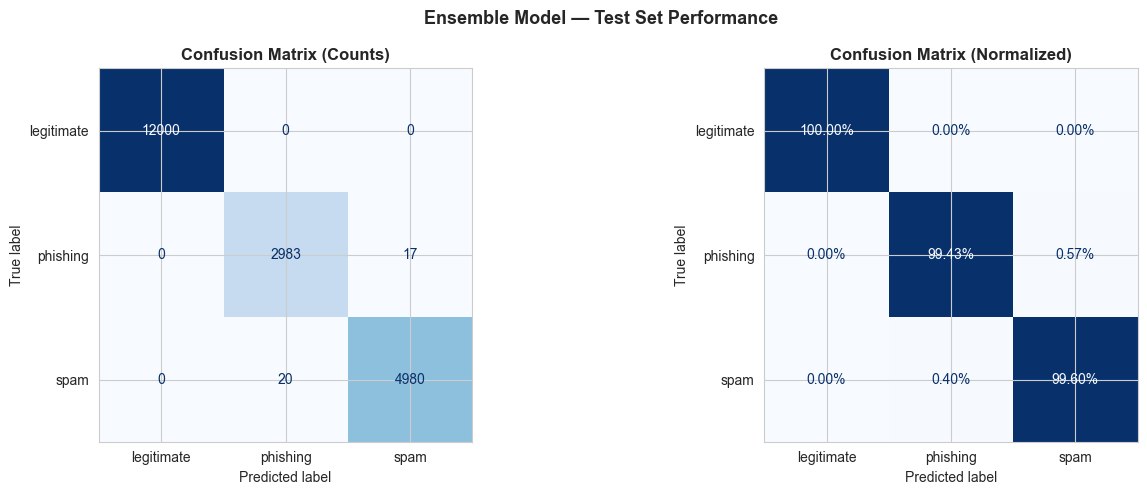

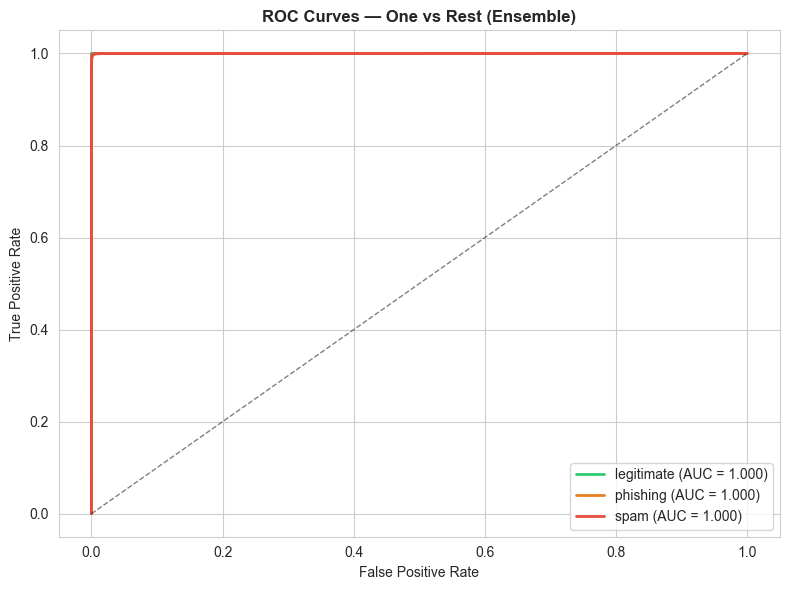

In [50]:
#  FINAL EVALUATION ON HELD-OUT TEST SET

y_test_pred  = ensemble_predict(X_test)
y_test_proba = ensemble_predict_proba(X_test)

test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

print('='*60)
print('FINAL TEST SET RESULTS (Ensemble)')
print('='*60)
print(f'Weighted F1 : {test_f1:.4f}')
print(f'Macro F1    : {test_f1_macro:.4f}')
print(f'\n{classification_report(y_test, y_test_pred, target_names=le.classes_)}')

#  Confusion Matrix 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_test_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=le.classes_)
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False,
           values_format='.2%')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

plt.suptitle('Ensemble Model — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

#  ROC Curves 
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2ecc71', '#e67e22', '#e74c3c']
for i, (cls, col) in enumerate(zip(le.classes_, colors)):
    y_bin = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_bin, y_test_proba[:, i])
    auc = roc_auc_score(y_bin, y_test_proba[:, i])
    ax.plot(fpr, tpr, color=col, lw=2, label=f'{cls} (AUC = {auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One vs Rest (Ensemble)', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — SHAP Explainability (Layer 3)

 Computing SHAP values (this may take ~60 seconds)...
 SHAP computed in 2.9s
   SHAP array shape: (2000, 38, 3)
   Classes: ['legitimate', 'phishing', 'spam']


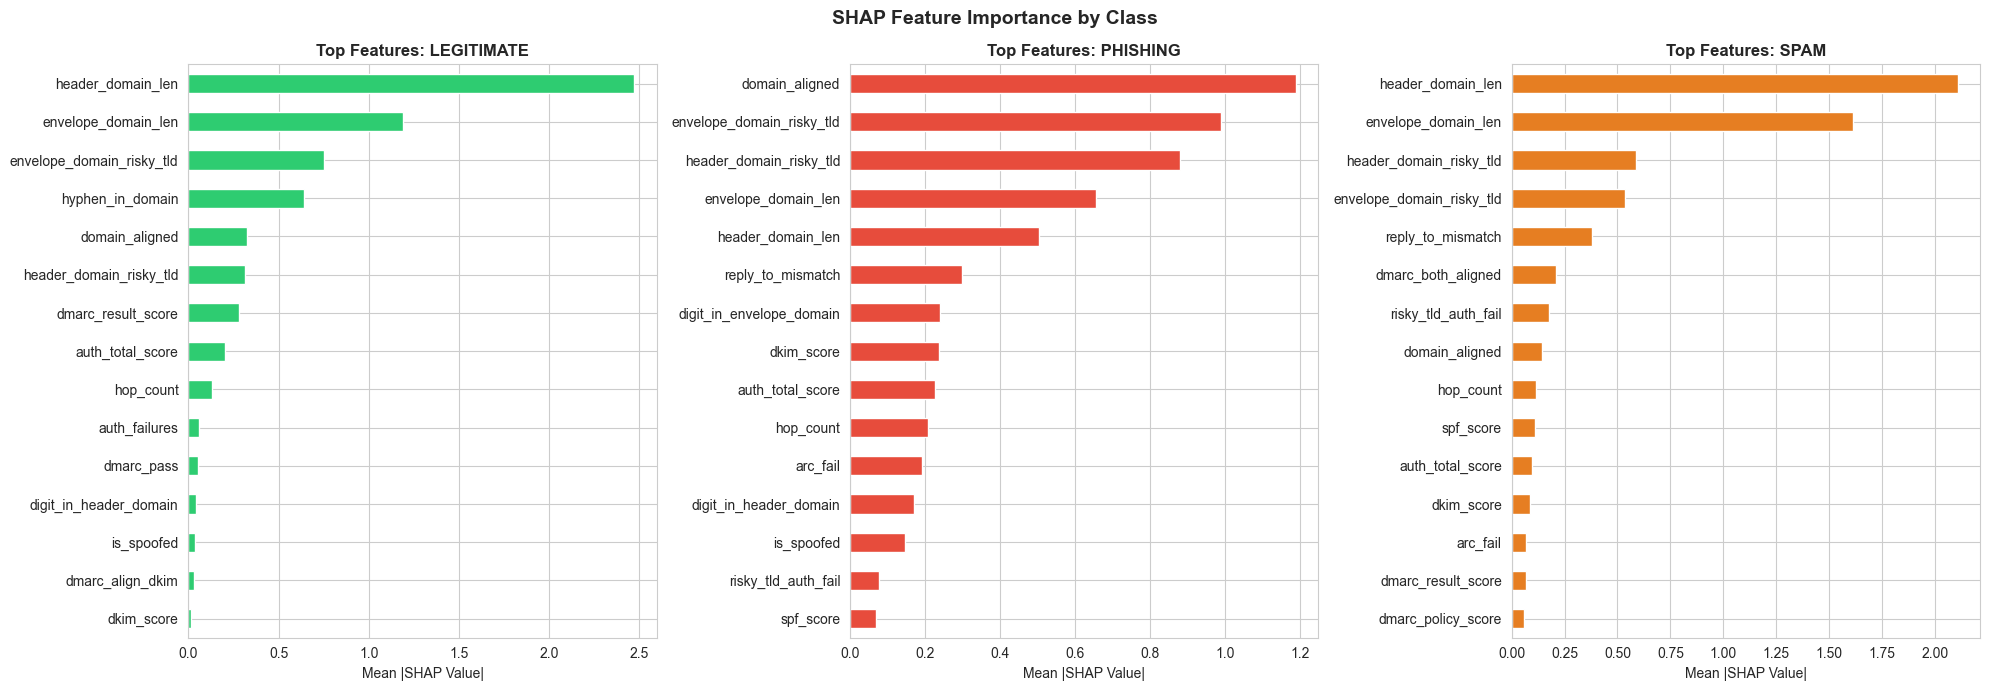


 SHAP Summary Plot (phishing class):


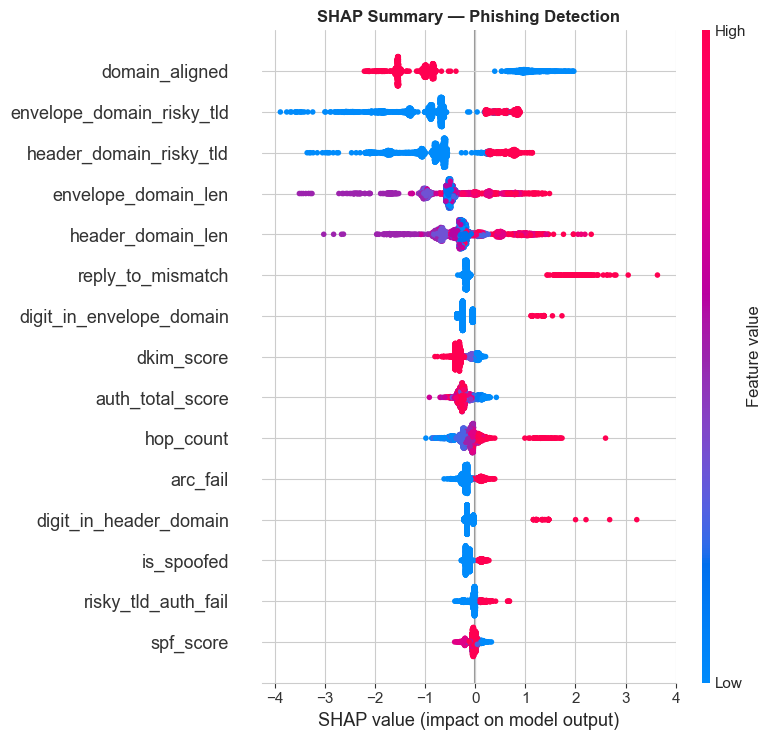

In [51]:

#  LAYER 3: SHAP EXPLAINABILITY
#  Explains WHY each email was flagged

print(' Computing SHAP values (this may take ~60 seconds)...')
t0 = time.time()

# Use XGBoost for SHAP (native tree explainer — fast & exact)
explainer    = shap.TreeExplainer(xgb_model)
X_test_sample = X_test.iloc[:2000]  # Use 2K samples for speed
shap_values  = explainer.shap_values(X_test_sample)

print(f' SHAP computed in {time.time()-t0:.1f}s')
print(f'   SHAP array shape: {np.array(shap_values).shape}')
print(f'   Classes: {list(le.classes_)}')

# ── Global Feature Importance (SHAP) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, (cls, ax) in enumerate(zip(le.classes_, axes)):
    shap_cls = shap_values[i] if isinstance(shap_values, list) else shap_values[:, :, i]
    mean_abs = np.abs(shap_cls).mean(axis=0)
    feat_imp = pd.Series(mean_abs, index=X_test_sample.columns).sort_values(ascending=True)
    top15 = feat_imp.tail(15)

    colors_bar = ['#e74c3c' if cls=='phishing' else '#e67e22' if cls=='spam' else '#2ecc71'] * len(top15)
    top15.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(f'Top Features: {cls.upper()}', fontweight='bold')
    ax.set_xlabel('Mean |SHAP Value|')

plt.suptitle('SHAP Feature Importance by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SHAP Summary Plot (beeswarm) ──────────────────────────
print('\n SHAP Summary Plot (phishing class):')
phishing_idx = list(le.classes_).index('phishing')
shap_phish = shap_values[phishing_idx] if isinstance(shap_values, list) else shap_values[:,:,phishing_idx]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_phish, X_test_sample, show=False,
                  plot_type='dot', max_display=15)
plt.title('SHAP Summary — Phishing Detection', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_phishing.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Hybrid Pipeline (Layer 1 + Layer 2 Combined)

In [52]:

#  HYBRID PIPELINE: RULES + ML COMBINED
#  Final threat score = RULE_WEIGHT * rule_score
#                     + ML_WEIGHT   * ml_threat_prob


# Label index for non-legitimate classes
legit_idx    = list(le.classes_).index('legitimate')
phish_idx    = list(le.classes_).index('phishing')
spam_idx     = list(le.classes_).index('spam')

def ml_threat_probability(X_row):
    proba = ensemble_predict_proba(X_row.to_frame().T)
    return float(1 - proba[0][legit_idx])


class HybridEmailSecurityPipeline:

    def __init__(self, rule_engine, rf_model, xgb_model,
                 explainer, label_encoder, feature_cols):
        self.rule_engine   = rule_engine
        self.rf_model      = rf_model
        self.xgb_model     = xgb_model
        self.explainer     = explainer
        self.le            = label_encoder
        self.feature_cols  = feature_cols
        self.legit_idx     = list(label_encoder.classes_).index('legitimate')
        self.phish_idx     = list(label_encoder.classes_).index('phishing')
        self.spam_idx      = list(label_encoder.classes_).index('spam')

    def _get_top_shap_features(self, X_row, class_idx, top_n=5):
        try:
            sv = self.explainer.shap_values(X_row)
            if isinstance(sv, list):
                sv_cls = sv[class_idx][0]
            else:
                sv_cls = sv[0, :, class_idx]
            feat_names = self.feature_cols
            importance = sorted(zip(feat_names, sv_cls),
                                key=lambda x: abs(x[1]), reverse=True)
            return importance[:top_n]
        except Exception as e:
            return []

    def predict(self, raw_record: dict, explain: bool = True) -> dict:
       
        t_start = time.time()

        # ── Layer 1: Rule Engine ───────────────────────────
        rule_result = self.rule_engine.evaluate(raw_record)

        # ── Layer 2: ML Ensemble ───────────────────────────
        X_row = engineer_features(pd.DataFrame([raw_record]))
        X_row = X_row.reindex(columns=self.feature_cols, fill_value=0)

        rf_proba  = self.rf_model.predict_proba(X_row)[0]
        xgb_proba = self.xgb_model.predict_proba(X_row)[0]
        ml_proba  = RF_WEIGHT * rf_proba + XGB_WEIGHT * xgb_proba

        ml_pred_idx     = int(np.argmax(ml_proba))
        ml_pred_label   = self.le.classes_[ml_pred_idx]
        ml_threat_prob  = float(1 - ml_proba[self.legit_idx])

        p_legit   = float(ml_proba[self.legit_idx])
        p_spam    = float(ml_proba[self.spam_idx])
        p_phish   = float(ml_proba[self.phish_idx])

        # ── Hybrid Score ───────────────────────────────────
        hybrid_score = (
            CONFIG['RULE_WEIGHT'] * rule_result['rule_score'] +
            CONFIG['ML_WEIGHT']   * ml_threat_prob
        )

        # ── Final Verdict ──────────────────────────────────
        if hybrid_score >= CONFIG['BLOCK_THRESHOLD']:
            final_verdict = 'BLOCK'
            threat_level  = 'CRITICAL'
        elif hybrid_score >= CONFIG['QUARANTINE_THRESHOLD']:
            final_verdict = 'QUARANTINE'
            threat_level  = 'HIGH' if hybrid_score >= 0.65 else 'MEDIUM'
        else:
            final_verdict = 'ALLOW'
            threat_level  = 'LOW' if hybrid_score >= 0.25 else 'NONE'

        # ── Layer 3: SHAP Explanation ──────────────────────
        shap_features = []
        if explain and ml_pred_idx != self.legit_idx:
            shap_features = self._get_top_shap_features(X_row, ml_pred_idx)

        # ── Layer 4: Threat Report ─────────────────────────
        report = {
            'timestamp'       : datetime.utcnow().isoformat() + 'Z',
            'processing_ms'   : round((time.time() - t_start) * 1000, 2),

            # Final decision
            'verdict'         : final_verdict,
            'threat_level'    : threat_level,
            'hybrid_score'    : round(hybrid_score, 4),

            # ML results
            'ml_prediction'   : ml_pred_label,
            'ml_threat_prob'  : round(ml_threat_prob, 4),
            'p_legitimate'    : round(p_legit, 4),
            'p_spam'          : round(p_spam, 4),
            'p_phishing'      : round(p_phish, 4),

            # Rule engine results
            'rule_score'      : rule_result['rule_score'],
            'rule_verdict'    : rule_result['rule_verdict'],
            'rule_flags'      : [r['rule'] for r in rule_result['triggered_rules']],
            'rule_details'    : rule_result['triggered_rules'],

            # SHAP explanation
            'top_risk_features': [
                {'feature': f, 'shap_value': round(float(v), 4)}
                for f, v in shap_features
            ],

            # Email metadata
            'email_from'      : raw_record.get('from', ''),
            'email_subject'   : raw_record.get('subject', ''),
            'header_domain'   : raw_record.get('header_from_domain', ''),
            'envelope_domain' : raw_record.get('envelope_from_domain', ''),
            'spf_result'      : raw_record.get('spf_result', ''),
            'dkim_result'     : raw_record.get('dkim_result', ''),
            'dmarc_result'    : raw_record.get('dmarc_result', ''),
            'true_label'      : raw_record.get('label', 'unknown'),
        }
        return report


# Instantiate pipeline
pipeline = HybridEmailSecurityPipeline(
    rule_engine   = rule_engine,
    rf_model      = rf_model,
    xgb_model     = xgb_model,
    explainer     = explainer,
    label_encoder = le,
    feature_cols  = list(X.columns),
)

print(' Hybrid pipeline initialized')

 Hybrid pipeline initialized


## Cell 13 — Real-Time Prediction & Threat Report

In [53]:
#  THREAT REPORT PRINTER


VERDICT_COLORS = {
    'BLOCK'      : '🔴',
    'QUARANTINE' : '🟡',
    'ALLOW'      : '🟢',
}
THREAT_COLORS = {
    'CRITICAL': '🚨',
    'HIGH'    : '⚠️ ',
    'MEDIUM'  : '🔔',
    'LOW'     : '📋',
    'NONE'    : '✅',
}

def print_threat_report(report):
    """Print a human-readable threat report"""
    v = report['verdict']
    t = report['threat_level']
    print('\n' + '═'*65)
    print(f"  {VERDICT_COLORS[v]} VERDICT: {v}  |  {THREAT_COLORS[t]} THREAT LEVEL: {t}")
    print('═'*65)
    print(f"  Hybrid Score    : {report['hybrid_score']:.4f}  "
          f"(Rule:{report['rule_score']:.3f} + ML:{report['ml_threat_prob']:.3f})")
    print(f"  Processing time : {report['processing_ms']} ms")
    print('─'*65)
    print(f"  From            : {report['email_from']}")
    print(f"  Subject         : {report['email_subject'][:60]}")
    print(f"  Header Domain   : {report['header_domain']}")
    print(f"  Envelope Domain : {report['envelope_domain']}")
    print('─'*65)
    print(f"  Auth Results:")
    print(f"    SPF    : {report['spf_result']:10s}  "
          f"DKIM : {report['dkim_result']:10s}  "
          f"DMARC: {report['dmarc_result']}")
    print('─'*65)
    print(f"  ML Probabilities:")
    print(f"    Legitimate : {report['p_legitimate']:.2%}")
    print(f"    Spam       : {report['p_spam']:.2%}")
    print(f"    Phishing   : {report['p_phishing']:.2%}")
    print(f"    → Predicted: {report['ml_prediction'].upper()}")
    if report['rule_flags']:
        print('─'*65)
        print(f"  Rule Flags Triggered ({len(report['rule_flags'])}):")
        for detail in report['rule_details']:
            print(f"    [{detail['score']:+.1f}] ⚑ {detail['rule']:28s}")
            print(f"         → {detail['reason']}")
    if report['top_risk_features']:
        print('─'*65)
        print(f"  Top Risk Features (SHAP):")
        for feat in report['top_risk_features']:
            direction = '▲ increases risk' if feat['shap_value'] > 0 else '▼ decreases risk'
            print(f"    {feat['feature']:30s}  SHAP={feat['shap_value']:+.4f}  {direction}")
    print('─'*65)
    print(f"  True Label (from dataset): {report['true_label'].upper()}")
    print('═'*65 + '\n')


#  RUN ON 3 SAMPLE EMAILS

test_samples = {
    'phishing' : df[df['label']=='phishing'].iloc[2].to_dict(),
    'spam'     : df[df['label']=='spam'].iloc[5].to_dict(),
    'legitimate': df[df['label']=='legitimate'].iloc[3].to_dict(),
}

for email_type, record in test_samples.items():
    print(f'\n Analyzing {email_type.upper()} email...')
    report = pipeline.predict(record, explain=True)
    print_threat_report(report)


 Analyzing PHISHING email...

═════════════════════════════════════════════════════════════════
  🔴 VERDICT: BLOCK  |  🚨 THREAT LEVEL: CRITICAL
═════════════════════════════════════════════════════════════════
  Hybrid Score    : 1.0000  (Rule:1.000 + ML:1.000)
  Processing time : 95.07 ms
─────────────────────────────────────────────────────────────────
  From            : melissa91@urgent-action.ml
  Subject         : Project Update - Matrix Efficient Schemas
  Header Domain   : urgent-action.ml
  Envelope Domain : account-suspended.gq
─────────────────────────────────────────────────────────────────
  Auth Results:
    SPF    : softfail    DKIM : fail        DMARC: reject
─────────────────────────────────────────────────────────────────
  ML Probabilities:
    Legitimate : 0.00%
    Spam       : 0.00%
    Phishing   : 100.00%
    → Predicted: PHISHING
─────────────────────────────────────────────────────────────────
  Rule Flags Triggered (10):
    [+1.2] ⚑ SPF_SOFTFAIL            

## Cell 14 — Batch Evaluation on Test Set

In [54]:

#  BATCH EVALUATION: Run full pipeline on test set
#  Measures hybrid pipeline accuracy vs ground truth


print(f' Running hybrid pipeline on {len(df_test):,} test records...')
print('   (SHAP disabled for batch speed)')
t0 = time.time()

verdicts, hybrid_scores, ml_preds = [], [], []
true_labels = []

for _, row in tqdm(df_test.iterrows(), total=len(df_test), desc='Evaluating'):
    record = row.to_dict()
    r = pipeline.predict(record, explain=False)
    verdicts.append(r['verdict'])
    hybrid_scores.append(r['hybrid_score'])
    ml_preds.append(r['ml_prediction'])
    true_labels.append(record['label'])

elapsed = time.time() - t0

# ── Hybrid Pipeline Accuracy 
results_df = pd.DataFrame({
    'true_label'   : true_labels,
    'ml_prediction': ml_preds,
    'verdict'      : verdicts,
    'hybrid_score' : hybrid_scores,
})

pipeline_f1 = f1_score(
    results_df['true_label'],
    results_df['ml_prediction'],
    average='weighted'
)

print(f'\n Batch evaluation done in {elapsed:.1f}s '
      f'({len(df_test)/elapsed:.0f} emails/sec)')
print(f'\n Hybrid Pipeline Results:')
print(f'   Weighted F1    : {pipeline_f1:.4f}')
print(f'\n Verdict Distribution:')
print(results_df['verdict'].value_counts())
print(f'\n Verdict vs True Label:')
print(pd.crosstab(results_df['true_label'], results_df['verdict'], normalize='index').round(3))

 Running hybrid pipeline on 20,000 test records...
   (SHAP disabled for batch speed)


Evaluating: 100%|████████████████████████████████████████████████████████████████| 20000/20000 [32:45<00:00, 10.18it/s]



 Batch evaluation done in 1965.5s (10 emails/sec)

 Hybrid Pipeline Results:
   Weighted F1    : 0.9982

 Verdict Distribution:
verdict
ALLOW         12000
BLOCK          7150
QUARANTINE      850
Name: count, dtype: int64

 Verdict vs True Label:
verdict     ALLOW  BLOCK  QUARANTINE
true_label                          
legitimate    1.0   0.00        0.00
phishing      0.0   1.00        0.00
spam          0.0   0.83        0.17


## Cell 15 — Full Performance Dashboard

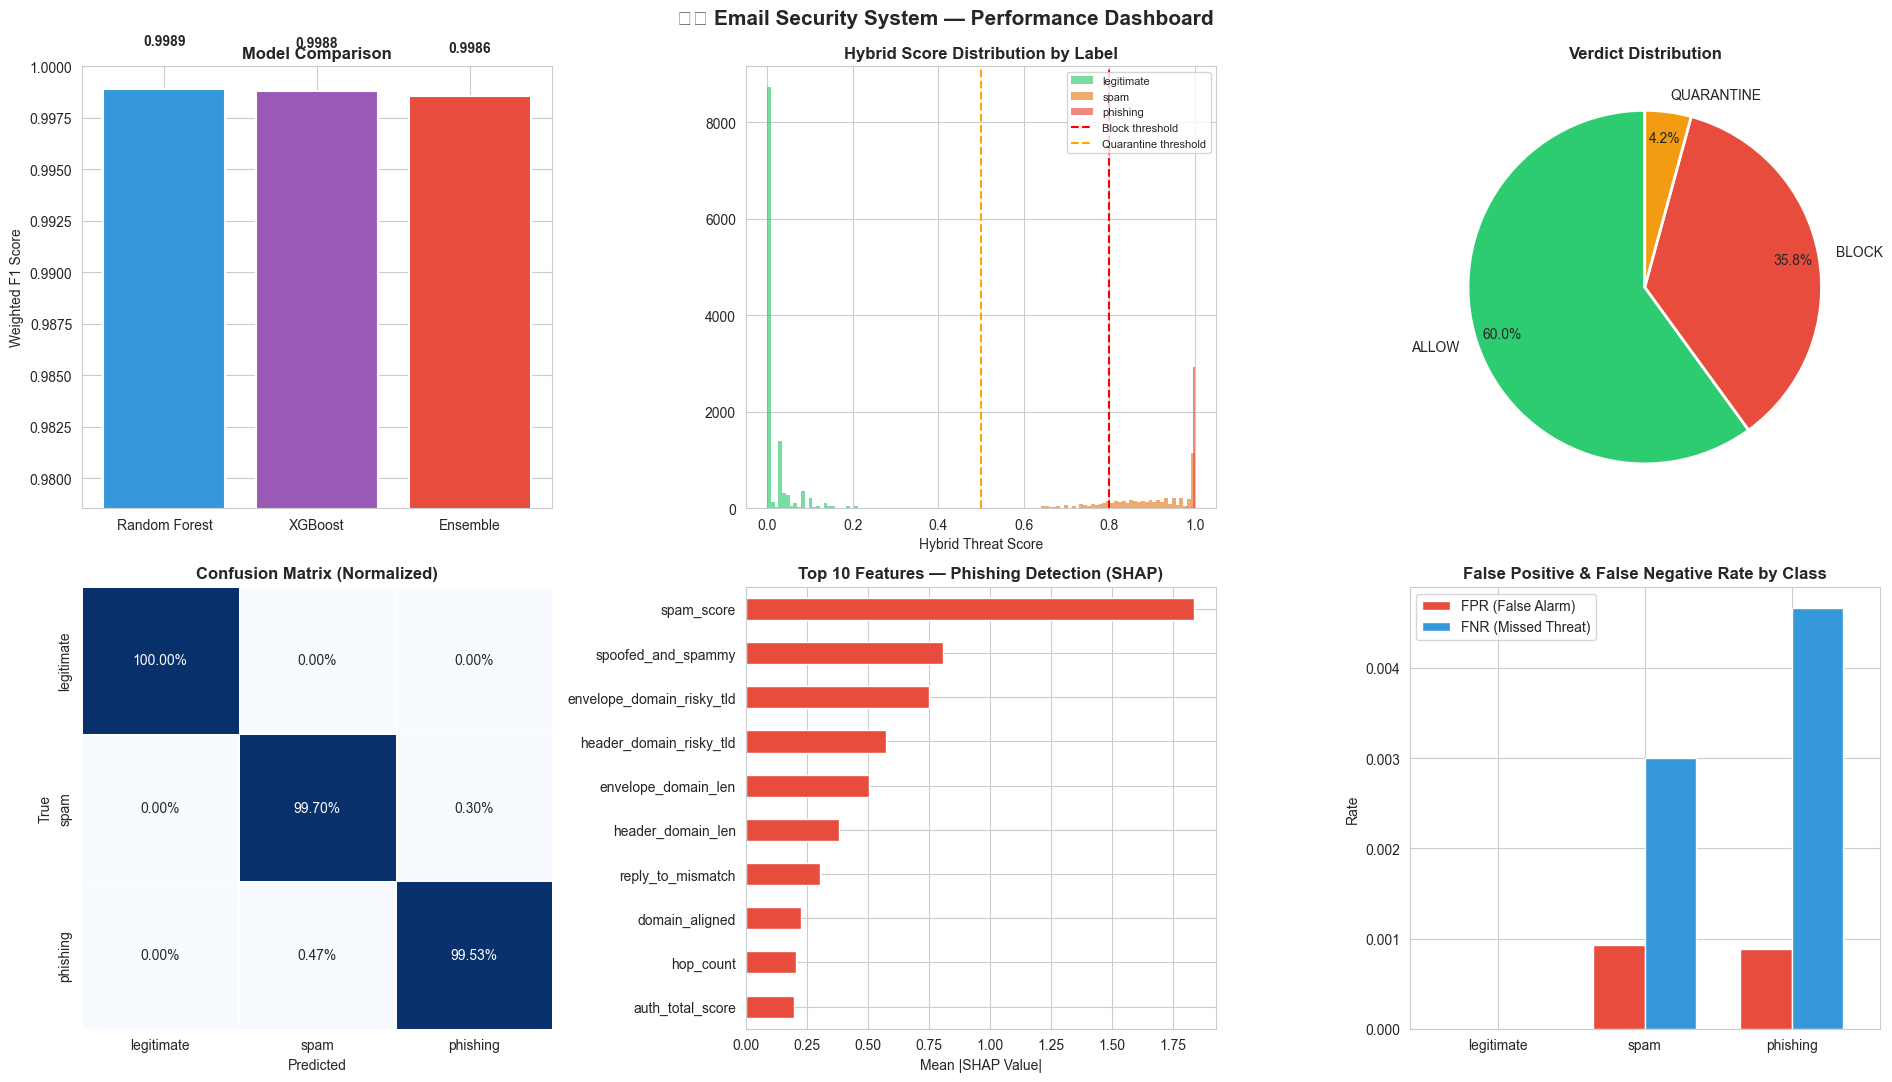

✅ Dashboard saved → security_system_dashboard.png


In [16]:
# ══════════════════════════════════════════════════════════
#  PERFORMANCE DASHBOARD
# ══════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle('🛡️ Email Security System — Performance Dashboard',
             fontsize=15, fontweight='bold')

colors_map = {'legitimate':'#2ecc71','spam':'#e67e22','phishing':'#e74c3c'}
verdict_colors = {'ALLOW':'#2ecc71','QUARANTINE':'#f39c12','BLOCK':'#e74c3c'}

# 1. Model Comparison Bar
ax = axes[0,0]
models = ['Random Forest', 'XGBoost', 'Ensemble']
scores = [val_f1_rf, val_f1_xgb, test_f1]
bars = ax.bar(models, scores, color=['#3498db','#9b59b6','#e74c3c'],
               edgecolor='white', linewidth=1.5)
ax.set_ylim(min(scores)-0.02, 1.0)
ax.set_ylabel('Weighted F1 Score')
ax.set_title('Model Comparison', fontweight='bold')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Hybrid Score Distribution by True Label
ax = axes[0,1]
for lbl in ['legitimate','spam','phishing']:
    subset = results_df[results_df['true_label']==lbl]['hybrid_score']
    ax.hist(subset, bins=40, alpha=0.65,
            color=colors_map[lbl], label=lbl, edgecolor='none')
ax.axvline(CONFIG['BLOCK_THRESHOLD'], color='red', ls='--', lw=1.5, label='Block threshold')
ax.axvline(CONFIG['QUARANTINE_THRESHOLD'], color='orange', ls='--', lw=1.5, label='Quarantine threshold')
ax.set_title('Hybrid Score Distribution by Label', fontweight='bold')
ax.set_xlabel('Hybrid Threat Score')
ax.legend(fontsize=8)

# 3. Verdict Pie
ax = axes[0,2]
vc = results_df['verdict'].value_counts()
ax.pie(vc.values, labels=vc.index, autopct='%1.1f%%',
       colors=[verdict_colors[v] for v in vc.index],
       startangle=90, pctdistance=0.85,
       wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Verdict Distribution', fontweight='bold')

# 4. Confusion Matrix Heatmap
ax = axes[1,0]
cm_norm = confusion_matrix(results_df['true_label'],
                           results_df['ml_prediction'],
                           labels=['legitimate','spam','phishing'],
                           normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['legitimate','spam','phishing'],
            yticklabels=['legitimate','spam','phishing'],
            ax=ax, cbar=False, linewidths=0.5)
ax.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

# 5. Top SHAP Features (Global)
ax = axes[1,1]
phish_sv = shap_values[phishing_idx] if isinstance(shap_values, list) else shap_values[:,:,phishing_idx]
mean_shap = pd.Series(np.abs(phish_sv).mean(axis=0), index=X_test_sample.columns)
top10 = mean_shap.sort_values().tail(10)
top10.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('Top 10 Features — Phishing Detection (SHAP)', fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')

# 6. False Positive / False Negative Rate
ax = axes[1,2]
metrics_data = []
for lbl in ['legitimate','spam','phishing']:
    tp = ((results_df['true_label']==lbl) & (results_df['ml_prediction']==lbl)).sum()
    fn = ((results_df['true_label']==lbl) & (results_df['ml_prediction']!=lbl)).sum()
    fp = ((results_df['true_label']!=lbl) & (results_df['ml_prediction']==lbl)).sum()
    tn = ((results_df['true_label']!=lbl) & (results_df['ml_prediction']!=lbl)).sum()
    fpr = fp / (fp + tn) if (fp+tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn+tp) > 0 else 0
    metrics_data.append({'Class':lbl, 'FPR':fpr, 'FNR':fnr})

metrics_df = pd.DataFrame(metrics_data).set_index('Class')
metrics_df.plot(kind='bar', ax=ax, color=['#e74c3c','#3498db'],
                edgecolor='white', width=0.7)
ax.set_title('False Positive & False Negative Rate by Class', fontweight='bold')
ax.set_ylabel('Rate')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(['FPR (False Alarm)', 'FNR (Missed Threat)'])

plt.tight_layout()
plt.savefig('security_system_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard saved → security_system_dashboard.png')

## Cell 16 — Save Models & Final Summary

In [20]:
# ══════════════════════════════════════════════════════════
#  SAVE ALL MODELS & ARTIFACTS
# ══════════════════════════════════════════════════════════

# Save label encoder
joblib.dump(le, f"{CONFIG['MODEL_DIR']}label_encoder.pkl")

# Save feature columns list (needed for inference)
with open(f"{CONFIG['MODEL_DIR']}feature_cols.json", 'w') as f:
    json.dump(list(X.columns), f)

# Save config
with open(f"{CONFIG['MODEL_DIR']}config.json", 'w') as f:
    json.dump(CONFIG, f, indent=2)

# Save batch results
results_df.to_csv('pipeline_test_results.csv', index=False)

print('='*65)
print('  🛡️  EMAIL SECURITY SYSTEM — COMPLETE')
print('='*65)
print(f'  Random Forest F1 (val)  : {val_f1_rf:.4f}')
print(f'  XGBoost F1 (val)        : {val_f1_xgb:.4f}')
print(f'  Ensemble F1 (test)      : {test_f1:.4f}')
print(f'  Hybrid Pipeline F1      : {pipeline_f1:.4f}')
print('─'*65)
print('  Saved files:')
saved = [
    ('models/random_forest.pkl',   'Random Forest model'),
    ('models/xgboost.pkl',         'XGBoost model'),
    ('models/label_encoder.pkl',   'Label encoder'),
    ('models/feature_cols.json',   'Feature column names'),
    ('models/config.json',         'Pipeline configuration'),
    ('pipeline_test_results.csv',  'Batch test results'),
    ('confusion_matrix.png',       'Confusion matrix chart'),
    ('roc_curves.png',             'ROC curves chart'),
    ('shap_feature_importance.png','SHAP importance chart'),
    ('shap_summary_phishing.png',  'SHAP beeswarm plot'),
    ('security_system_dashboard.png','Full performance dashboard'),
]
for fname, desc in saved:
    exists = '✅' if os.path.exists(fname) else '❌'
    print(f'  {exists} {fname:45s} — {desc}')
print('='*65)
print('\n  ✅ System ready for real-time inference via pipeline.predict()')

  🛡️  EMAIL SECURITY SYSTEM — COMPLETE
  Random Forest F1 (val)  : 0.9989
  XGBoost F1 (val)        : 0.9988
  Ensemble F1 (test)      : 0.9986
  Hybrid Pipeline F1      : 0.9986
─────────────────────────────────────────────────────────────────
  Saved files:
  ✅ models/random_forest.pkl                      — Random Forest model
  ✅ models/xgboost.pkl                            — XGBoost model
  ✅ models/label_encoder.pkl                      — Label encoder
  ✅ models/feature_cols.json                      — Feature column names
  ✅ models/config.json                            — Pipeline configuration
  ✅ pipeline_test_results.csv                     — Batch test results
  ✅ confusion_matrix.png                          — Confusion matrix chart
  ✅ roc_curves.png                                — ROC curves chart
  ✅ shap_feature_importance.png                   — SHAP importance chart
  ✅ shap_summary_phishing.png                     — SHAP beeswarm plot
  ✅ security_system_dashboar

In [38]:
import json

# Load current feature cols
with open('models/feature_cols.json') as f:
    cols = json.load(f)

# Remove the spam_score columns
remove = ['spam_score', 'spam_score_high', 'spam_score_very_high', 'spoofed_and_spammy']
cols = [c for c in cols if c not in remove]

# Save back
with open('models/feature_cols.json', 'w') as f:
    json.dump(cols, f)

print('Done. New count:', len(cols))
print(cols)

Done. New count: 38
['spf_score', 'spf_pass', 'spf_fail', 'spf_softfail', 'spf_none', 'dkim_score', 'dkim_pass', 'dkim_fail', 'dkim_none', 'dmarc_result_score', 'dmarc_policy_score', 'dmarc_pass', 'dmarc_fail', 'dmarc_align_spf', 'dmarc_align_dkim', 'dmarc_both_aligned', 'dmarc_none_align', 'all_auth_pass', 'auth_failures', 'auth_total_score', 'domain_aligned', 'is_spoofed', 'header_domain_len', 'envelope_domain_len', 'domain_len_diff', 'header_domain_risky_tld', 'envelope_domain_risky_tld', 'digit_in_header_domain', 'digit_in_envelope_domain', 'hyphen_in_domain', 'hop_count', 'high_hop_count', 'reply_to_mismatch', 'arc_fail', 'arc_pass', 'spf_dkim_both_fail', 'misalign_dmarc_fail', 'risky_tld_auth_fail']
